In [14]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# TASK 2: ROOT FINDING ALGORITHMS
# ==========================================

def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
    """
    Newton-Raphson Method with Pandas tabulation.
    """
    data = []
    x_curr = x0
    
    # Store the first step specifically for geometric visualization later
    x1_first = None 
    
    for i in range(max_iter):
        f_val = f(x_curr)
        df_val = df(x_curr)
        
        # Safety Check: Prevent division by zero
        if abs(df_val) < 1e-12:
            print(f"Error at iteration {i}: Derivative is too close to zero. Stopping to prevent division by zero.")
            break
            
        x_next = x_curr - (f_val / df_val)
        error = abs(x_next - x_curr)
        
        data.append({
            'Iteration': i + 1,
            'x_i': x_curr,
            'f(x_i)': f_val,
            'f\'(x_i)': df_val,
            'Error': error
        })
        
        if i == 0:
            x1_first = x_next
            
        if error < tol:
            x_curr = x_next
            break
            
        x_curr = x_next
        
    df_results = pd.DataFrame(data)
    return x_curr, df_results, x1_first

def secant_method(f, x0, x1, tol=1e-6, max_iter=100):
    """
    Secant Method with Pandas tabulation.
    """
    data = []
    
    for i in range(max_iter):
        f_x0 = f(x0)
        f_x1 = f(x1)
        
        if abs(f_x1 - f_x0) < 1e-12:
            print(f"Error at iteration {i}: Denominator too close to zero.")
            break
            
        x_next = x1 - f_x1 * ((x1 - x0) / (f_x1 - f_x0))
        error = abs(x_next - x1)
        
        data.append({
            'Iteration': i + 1,
            'x_{i-1}': x0,
            'x_i': x1,
            'f(x_i)': f_x1,
            'Error': error
        })
        
        if error < tol:
            x1 = x_next
            break
            
        x0 = x1
        x1 = x_next
        
    df_results = pd.DataFrame(data)
    return x1, df_results

def false_position(f, a, b, tol=1e-6, max_iter=100):
    """
    False Position (Regula Falsi) Method with Pandas tabulation.
    """
    data = []
    if f(a) * f(b) >= 0:
        print("Error: The initial bounds a and b must bracket the root (f(a) and f(b) must have opposite signs).")
        return None, pd.DataFrame()
        
    c = a 
    for i in range(max_iter):
        f_a = f(a)
        f_b = f(b)
        
        c_old = c
        c = b - f_b * ((b - a) / (f_b - f_a))
        f_c = f(c)
        
        error = abs(c - c_old) if i > 0 else float('inf')
        
        data.append({
            'Iteration': i + 1,
            'a': a,
            'b': b,
            'c (root approx)': c,
            'f(c)': f_c,
            'Error': error if i > 0 else None
        })
        
        if abs(f_c) < tol or (i > 0 and error < tol):
            break
            
        if f_a * f_c < 0:
            b = c
        else:
            a = c
            
    df_results = pd.DataFrame(data)
    return c, df_results

In [15]:
# ==========================================
# TASK 1: QUINTIC TEST FUNCTIONS & INTERVALS
# ==========================================

# Function 1: f(x) = x^5 + x - 1 (Root ~0.75)
f1 = lambda x: x**5 + x - 1
df1 = lambda x: 5*x**4 + 1

# Function 2: f(x) = x^5 + 5x^3 - 4x + 1 (Root ~-1.07)
f2 = lambda x: x**5 + 5*x**3 - 4*x + 1
df2 = lambda x: 5*x**4 + 15*x**2 - 4

# Function 3: f(x) = x^5 + 2x^4 - x - 3 (Root ~1.08)
f3 = lambda x: x**5 + 2*x**4 - x - 3
df3 = lambda x: 5*x**4 + 8*x**3 - 1

# Function 4: f(x) = x^5 - 10 (Root ~1.58)
f4 = lambda x: x**5 - 10
df4 = lambda x: 5*x**4

# Function 5: f(x) = x^5 + 2x^2 + x - 0.5 (Root ~0.33)
f5 = lambda x: x**5 + 2*x**2 + x - 0.5
df5 = lambda x: 5*x**4 + 4*x + 1

# List format: (function, derivative, name, a, b)
# 'a' and 'b' represent the initial guesses / brackets.
functions = [
    (f1, df1, "f(x) = x^5 + x - 1", 0.0, 1.0),      
    (f2, df2, "f(x) = x^5 + 5x^3 - 4x + 1", -2.0, 0.0), 
    (f3, df3, "f(x) = x^5 + 2x^4 - x - 3", 0.0, 2.0), 
    (f4, df4, "f(x) = x^5 - 10", 1.0, 2.0),         
    (f5, df5, "f(x) = x^5 + 2x^2 + x - 0.5", 0.0, 1.0) 
]

# ==========================================
# TASK 3: VISUALIZATION (UPDATED FOR ALL METHODS)
# ==========================================

def plot_newton_step(f, df, x0, root, x1_first, title):
    """Visualizes the first step of the Newton-Raphson method."""
    x_min, x_max = min(x0, root) - 1.5, max(x0, root) + 1.5
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x_vals, y_vals, label="Function", color='blue', linewidth=2)
    plt.axhline(0, color='black', linewidth=1)
    
    # Initial point and tangent line
    f_x0 = f(x0)
    plt.plot(x0, f_x0, 'go', label=f'$x_0$ ({x0})')
    plt.vlines(x0, 0, f_x0, colors='green', linestyles='dashed', alpha=0.5)
    
    tangent_y = df(x0) * (x_vals - x0) + f_x0
    plt.plot(x_vals, tangent_y, 'orange', linestyle='--', label="Tangent Line")
    
    # Next guess and Root
    plt.plot(x1_first, 0, 'mo', label=f'$x_1$ ({x1_first:.3f})')
    if root is not None:
        plt.plot(root, 0, 'ro', markersize=6, label=f'Root ({root:.5f})')
    
    plt.xlim(x_min, x_max)
    plt.ylim(min(y_vals)-2, max(y_vals)+2) 
    plt.title(f"Newton-Raphson Geometry: {title}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

def plot_secant_step(f, x0, x1, root, title):
    """Visualizes the first step of the Secant method."""
    # Calculate the first new guess manually for the plot
    f_x0, f_x1 = f(x0), f(x1)
    x2 = x1 - f_x1 * ((x1 - x0) / (f_x1 - f_x0))
    
    x_min, x_max = min(x0, x1, x2, root) - 1, max(x0, x1, x2, root) + 1
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x_vals, y_vals, label="Function", color='blue', linewidth=2)
    plt.axhline(0, color='black', linewidth=1)
    
    # Initial points and secant line
    plt.plot([x0, x1], [f_x0, f_x1], 'go', label=f'Initial Guesses $x_0, x_1$')
    plt.vlines([x0, x1], 0, [f_x0, f_x1], colors='green', linestyles='dashed', alpha=0.5)
    
    slope = (f_x1 - f_x0) / (x1 - x0)
    secant_y = slope * (x_vals - x1) + f_x1
    plt.plot(x_vals, secant_y, 'orange', linestyle='--', label="Secant Line")
    
    # Next guess and Root
    plt.plot(x2, 0, 'mo', label=f'Next Guess $x_2$ ({x2:.3f})')
    if root is not None:
        plt.plot(root, 0, 'ro', markersize=6, label=f'Root ({root:.5f})')
        
    plt.xlim(x_min, x_max)
    plt.ylim(min(y_vals)-2, max(y_vals)+2)
    plt.title(f"Secant Method Geometry: {title}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

def plot_false_position_step(f, a, b, root, title):
    """Visualizes the first step of the False Position method."""
    f_a, f_b = f(a), f(b)
    
    # Check if they bracket the root for visualization purposes
    if f_a * f_b > 0:
        print(f"Cannot plot False Position for {title}: Initial bounds do not bracket the root.")
        return
        
    c = b - f_b * ((b - a) / (f_b - f_a))
    
    x_min, x_max = min(a, b, c, root) - 1, max(a, b, c, root) + 1
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x_vals, y_vals, label="Function", color='blue', linewidth=2)
    plt.axhline(0, color='black', linewidth=1)
    
    # Bracket points and secant line
    plt.plot([a, b], [f_a, f_b], 'go', label=f'Brackets a={a}, b={b}')
    plt.vlines([a, b], 0, [f_a, f_b], colors='green', linestyles='dashed', alpha=0.5)
    
    slope = (f_b - f_a) / (b - a)
    secant_y = slope * (x_vals - b) + f_b
    plt.plot(x_vals, secant_y, 'orange', linestyle='--', label="False Position Secant")
    
    # Next guess and Root
    plt.plot(c, 0, 'mo', label=f'Next Approx $c$ ({c:.3f})')
    if root is not None:
        plt.plot(root, 0, 'ro', markersize=6, label=f'Root ({root:.5f})')
        
    plt.xlim(x_min, x_max)
    plt.ylim(min(y_vals)-2, max(y_vals)+2)
    plt.title(f"False Position Geometry: {title}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.show()

BENCHMARK 1: f(x) = x^5 + x - 1

--- 1. Newton-Raphson Method (Initial guess x0 = 1.0) ---


,Iteration,x_i,f(x_i),f'(x_i),Error
0,1,1.000000,1.000000e+00,6.000000,1.666667e-01
1,2,0.833333,2.352109e-01,3.411265,6.895122e-02
2,3,0.764382,2.532928e-02,2.706916,9.357248e-03
3,4,0.755025,3.862882e-04,2.624857,1.471655e-04
4,5,0.754878,9.319893e-08,2.623590,3.552343e-08


Final Root: 0.754878


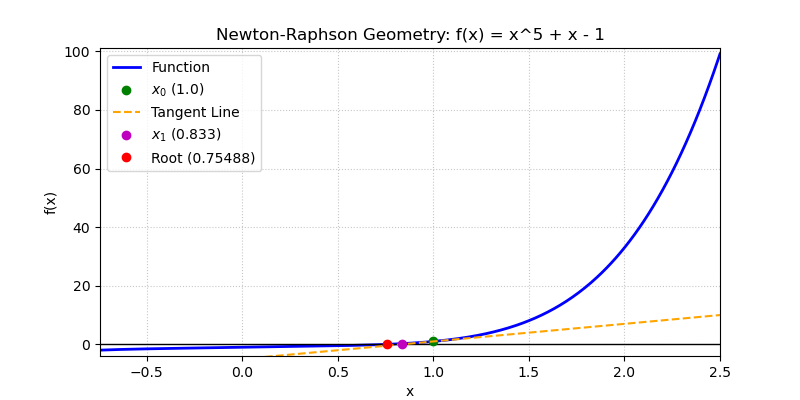


--- 2. Secant Method (Initial guesses x0 = 0.0, x1 = 1.0) ---


,Iteration,x_{i-1},x_i,f(x_i),Error
0,1,0.000000,1.000000,1.000000e+00,5.000000e-01
1,2,1.000000,0.500000,-4.687500e-01,1.595745e-01
2,3,0.500000,0.659574,-2.155955e-01,1.358993e-01
3,4,0.659574,0.795474,1.139885e-01,4.700155e-02
4,5,0.795474,0.748472,-1.663017e-02,5.984169e-03
5,6,0.748472,0.754456,-1.104406e-03,4.256765e-04
6,7,0.754456,0.754882,1.163137e-05,4.436412e-06
7,8,0.754882,0.754878,-8.034364e-09,3.062333e-09


Final Root: 0.754878


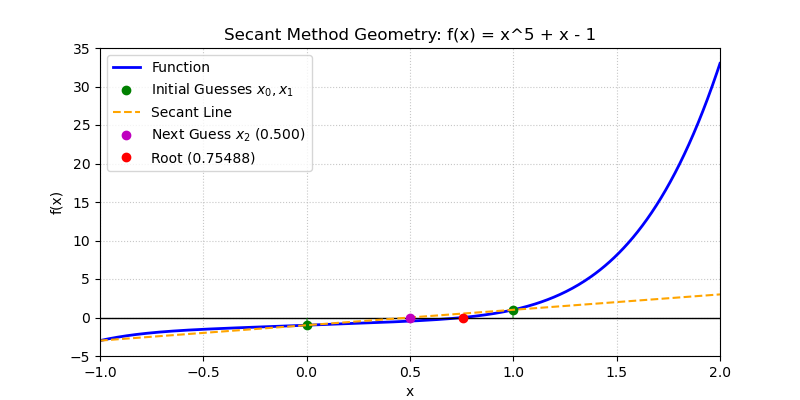


--- 3. False Position Method (Interval a = 0.0, b = 1.0) ---


,Iteration,a,b,c (root approx),f(c),Error
0,1,0.000000,1.0,0.500000,-0.468750,NaN
1,2,0.500000,1.0,0.659574,-0.215595,1.595745e-01
2,3,0.659574,1.0,0.719952,-0.086622,6.037716e-02
3,4,0.719952,1.0,0.742276,-0.032390,2.232446e-02
4,5,0.742276,1.0,0.750362,-0.011761,8.085681e-03
5,6,0.750362,1.0,0.753264,-0.004224,2.901785e-03
6,7,0.753264,1.0,0.754301,-0.001511,1.037731e-03
7,8,0.754301,1.0,0.754672,-0.000540,3.706333e-04
8,9,0.754672,1.0,0.754804,-0.000193,1.323131e-04
9,10,0.754804,1.0,0.754851,-0.000069,4.722683e-05


Final Root: 0.754877


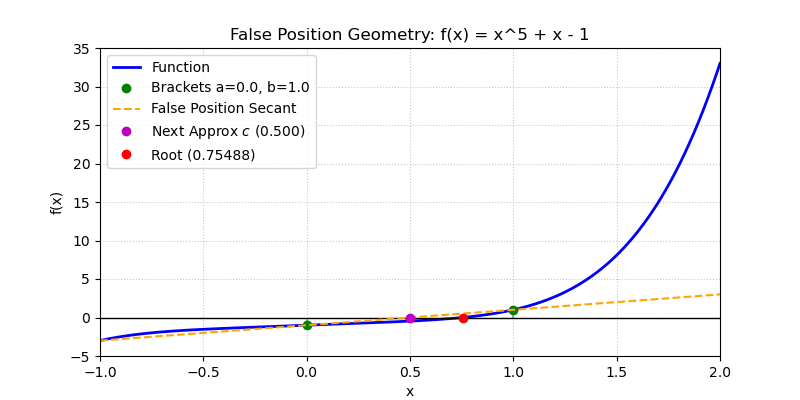




BENCHMARK 2: f(x) = x^5 + 5x^3 - 4x + 1

--- 1. Newton-Raphson Method (Initial guess x0 = 0.0) ---


,Iteration,x_i,f(x_i),f'(x_i),Error
0,1,0.000000,1.000000e+00,-4.000000,2.500000e-01
1,2,0.250000,7.910156e-02,-3.042969,2.599487e-02
2,3,0.275995,2.738971e-03,-2.828391,9.683850e-04
3,4,0.276963,4.084678e-06,-2.819949,1.448493e-06
4,5,0.276965,9.162338e-12,-2.819937,3.249123e-12


Final Root: 0.276965


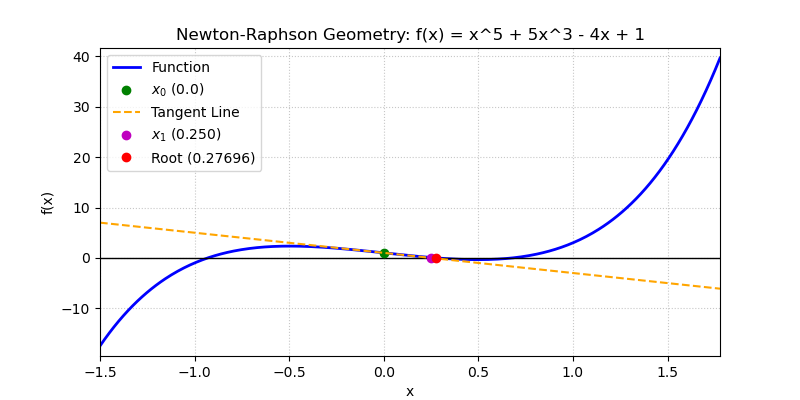


--- 2. Secant Method (Initial guesses x0 = -2.0, x1 = 0.0) ---


,Iteration,x_{i-1},x_i,f(x_i),Error
0,1,-2.000000,0.000000,1.000000e+00,3.125000e-02
1,2,0.000000,-0.031250,1.124847e+00,2.815556e-01
2,3,-0.031250,0.250306,7.817197e-02,2.102825e-02
3,4,0.250306,0.271334,1.601603e-02,5.418455e-03
4,5,0.271334,0.276752,5.990965e-04,2.105592e-04
5,6,0.276752,0.276963,5.135963e-06,1.820701e-06
6,7,0.276963,0.276965,1.688127e-09,5.986385e-10


Final Root: 0.276965


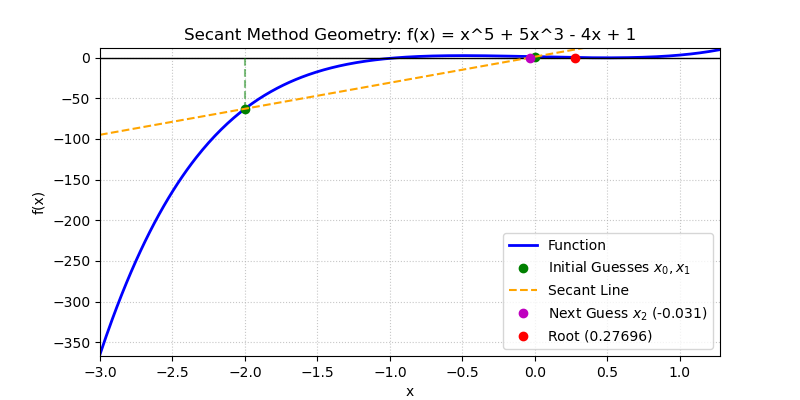


--- 3. False Position Method (Interval a = -2.0, b = 0.0) ---


,Iteration,a,b,c (root approx),f(c),Error
0,1,-2.0,0.000000,-0.031250,1.124847,NaN
1,2,-2.0,-0.031250,-0.065785,1.261715,3.453487e-02
2,3,-2.0,-0.065785,-0.103761,1.409447,3.797639e-02
3,4,-2.0,-0.103761,-0.145256,1.565635,4.149467e-02
4,5,-2.0,-0.145256,-0.190231,1.726255,4.497520e-02
...,...,...,...,...,...,...
57,58,-2.0,-0.930187,-0.930190,0.000114,2.468953e-06
58,59,-2.0,-0.930190,-0.930192,0.000089,1.935570e-06
59,60,-2.0,-0.930192,-0.930193,0.000070,1.517415e-06
60,61,-2.0,-0.930193,-0.930194,0.000055,1.189596e-06


Final Root: -0.930195


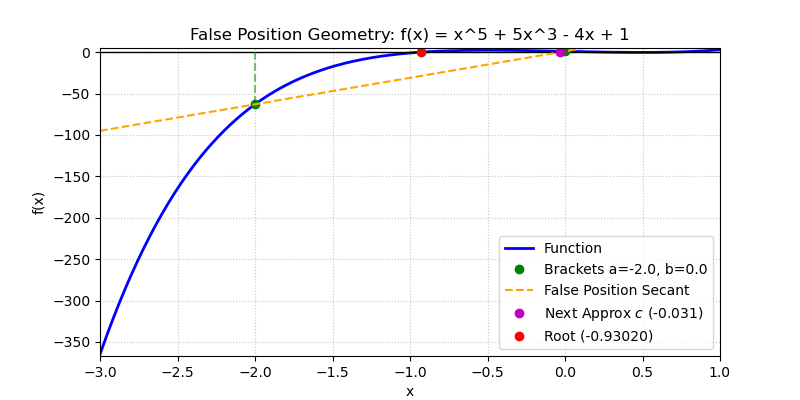




BENCHMARK 3: f(x) = x^5 + 2x^4 - x - 3

--- 1. Newton-Raphson Method (Initial guess x0 = 2.0) ---


,Iteration,x_i,f(x_i),f'(x_i),Error
0,1,2.000000,5.900000e+01,143.000000,4.125874e-01
1,2,1.587413,1.819190e+01,62.749642,2.899124e-01
2,3,1.297500,5.048258e+00,30.645777,1.647293e-01
3,4,1.132771,1.025414e+00,18.860923,5.436712e-02
4,5,1.078404,8.502488e-02,15.795394,5.382891e-03
5,6,1.073021,7.646051e-04,15.511892,4.929154e-05
6,7,1.072972,6.358404e-08,15.509312,4.099733e-09


Final Root: 1.072972


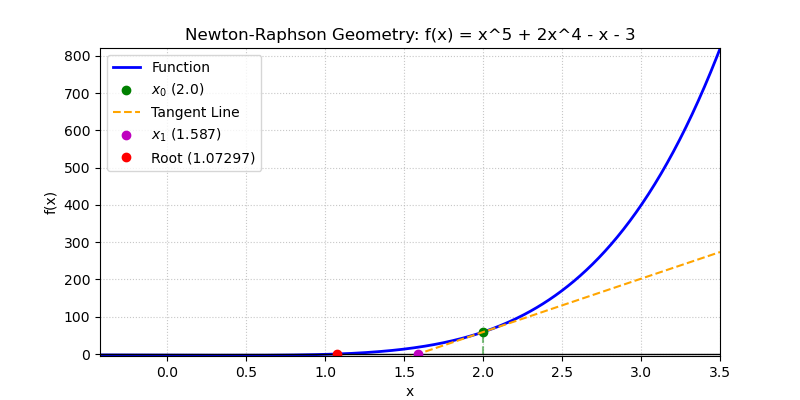


--- 2. Secant Method (Initial guesses x0 = 0.0, x1 = 2.0) ---


,Iteration,x_{i-1},x_i,f(x_i),Error
0,1,0.000000,2.000000,5.900000e+01,1.903226
1,2,2.000000,0.096774,-3.096590e+00,0.094909
2,3,0.096774,0.191683,-3.188724e+00,3.284762
3,4,0.191683,-3.093079,-9.995648e+01,3.393002
4,5,-3.093079,0.299924,-3.281313e+00,0.115164
...,...,...,...,...,...
95,96,0.428928,0.428983,-3.346724e+00,16.793944
96,97,0.428983,-16.364961,-1.030288e+06,16.793999
97,98,-16.364961,0.429038,-3.346735e+00,0.000055
98,99,0.429038,0.429092,-3.346745e+00,16.849568


Final Root: 0.429146


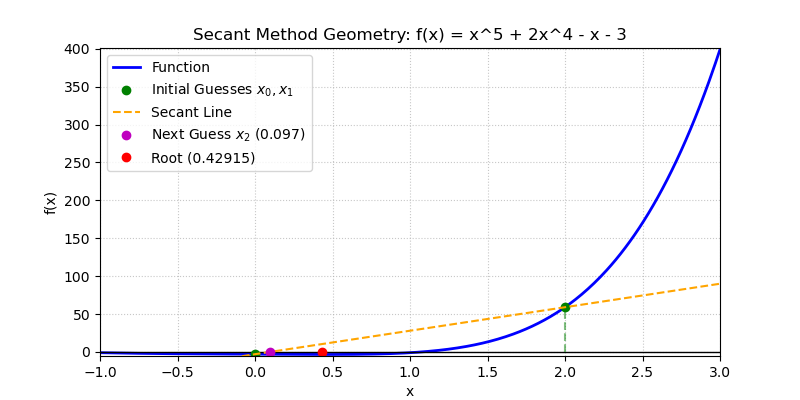


--- 3. False Position Method (Interval a = 0.0, b = 2.0) ---


,Iteration,a,b,c (root approx),f(c),Error
0,1,0.000000,2.0,0.096774,-3.096590,NaN
1,2,0.096774,2.0,0.191683,-3.188724,9.490876e-02
2,3,0.191683,2.0,0.284404,-3.269459,9.272138e-02
3,4,0.284404,2.0,0.374482,-3.327784,9.007737e-02
4,5,0.374482,2.0,0.461271,-3.349846,8.678914e-02
5,6,0.461271,2.0,0.543942,-3.321244,8.267070e-02
6,7,0.543942,2.0,0.621538,-3.230312,7.759673e-02
7,8,0.621538,2.0,0.693093,-3.071627,7.155455e-02
8,9,0.693093,2.0,0.757765,-2.848488,6.467258e-02
9,10,0.757765,2.0,0.814978,-2.573160,5.721224e-02


Final Root: 1.072969


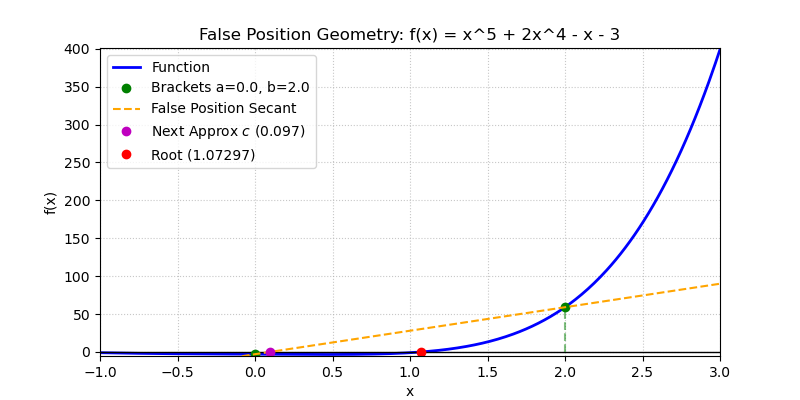




BENCHMARK 4: f(x) = x^5 - 10

--- 1. Newton-Raphson Method (Initial guess x0 = 2.0) ---


,Iteration,x_i,f(x_i),f'(x_i),Error
0,1,2.000000,22.000000,80.000000,2.750000e-01
1,2,1.725000,5.273744,44.271721,1.191222e-01
2,3,1.605878,0.679785,33.252171,2.044332e-02
3,4,1.585435,0.017089,31.590989,5.409395e-04
4,5,1.584894,0.000012,31.547897,3.695078e-07


Final Root: 1.584893


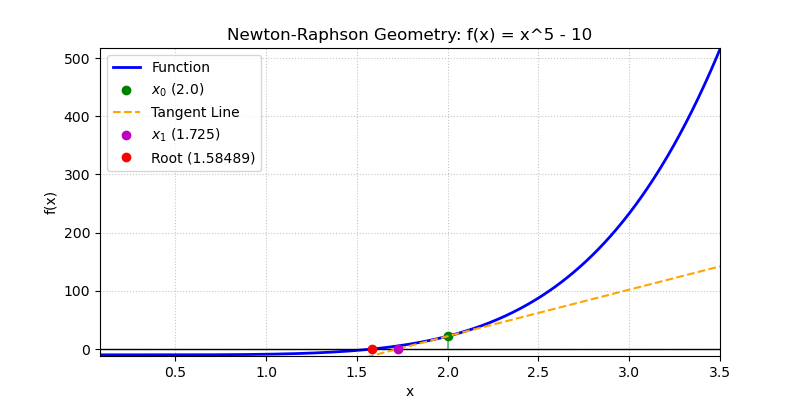


--- 2. Secant Method (Initial guesses x0 = 1.0, x1 = 2.0) ---


,Iteration,x_{i-1},x_i,f(x_i),Error
0,1,1.000000,2.000000,2.200000e+01,7.096774e-01
1,2,2.000000,1.290323,-6.423226e+00,1.603765e-01
2,3,1.290323,1.450699,-3.574799e+00,2.012738e-01
3,4,1.450699,1.651973,2.303102e+00,7.886390e-02
4,5,1.651973,1.573109,-3.662776e-01,1.082127e-02
5,6,1.573109,1.583930,-3.034017e-02,9.773222e-04
6,7,1.583930,1.584908,4.553843e-04,1.445200e-05
7,8,1.584908,1.584893,-5.536505e-07,1.754922e-08


Final Root: 1.584893


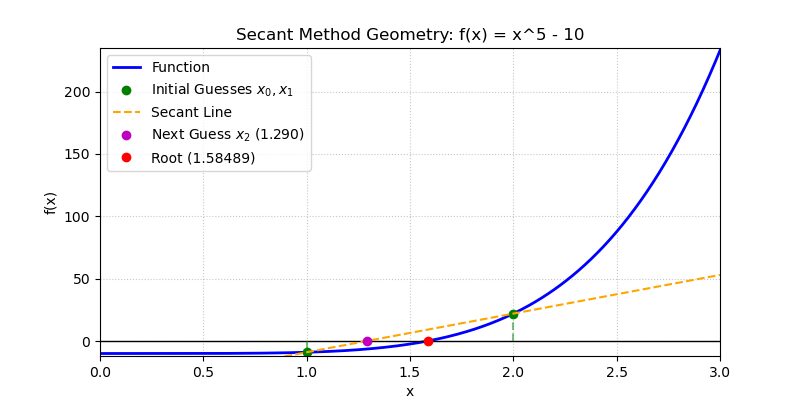


--- 3. False Position Method (Interval a = 1.0, b = 2.0) ---


,Iteration,a,b,c (root approx),f(c),Error
0,1,1.000000,2.0,1.290323,-6.423226,NaN
1,2,1.290323,2.0,1.450699,-3.574799,1.603765e-01
2,3,1.450699,2.0,1.527479,-1.684721,7.678028e-02
3,4,1.527479,2.0,1.561090,-0.728710,3.361093e-02
4,5,1.561090,2.0,1.575162,-0.303242,1.407198e-02
5,6,1.575162,2.0,1.580939,-0.124140,5.776232e-03
6,7,1.580939,2.0,1.583290,-0.050478,2.351380e-03
7,8,1.583290,2.0,1.584244,-0.020469,9.539284e-04
8,9,1.584244,2.0,1.584630,-0.008291,3.864594e-04
9,10,1.584630,2.0,1.584787,-0.003357,1.564755e-04


Final Root: 1.584893


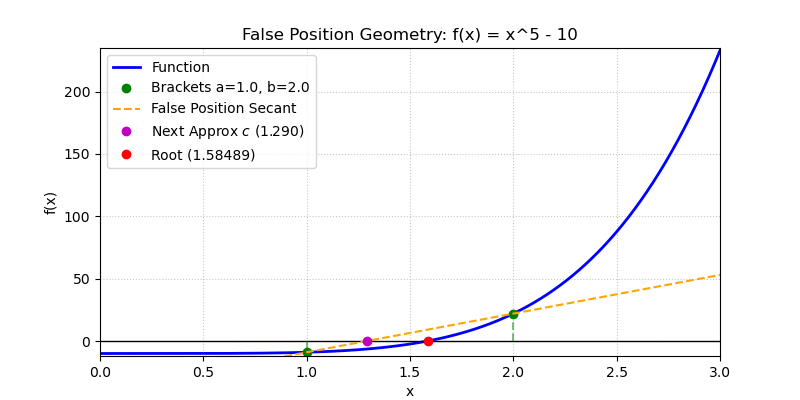




BENCHMARK 5: f(x) = x^5 + 2x^2 + x - 0.5

--- 1. Newton-Raphson Method (Initial guess x0 = 1.0) ---


,Iteration,x_i,f(x_i),f'(x_i),Error
0,1,1.000000,3.500000e+00,10.000000,3.500000e-01
1,2,0.650000,1.111029e+00,4.492531,2.473058e-01
2,3,0.402694,2.376090e-01,2.742260,8.664712e-02
3,4,0.316047,1.897184e-02,2.314074,8.198457e-03
4,5,0.307849,1.551048e-04,2.276302,6.813895e-05
5,6,0.307780,1.064011e-08,2.275990,4.674936e-09


Final Root: 0.307780


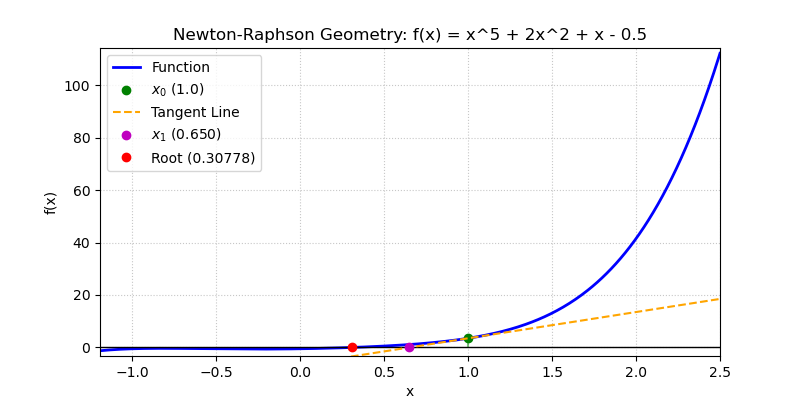


--- 2. Secant Method (Initial guesses x0 = 0.0, x1 = 1.0) ---


,Iteration,x_{i-1},x_i,f(x_i),Error
0,1,0.000000,1.000000,3.500000e+00,8.750000e-01
1,2,1.000000,0.125000,-3.437195e-01,7.824571e-02
2,3,0.125000,0.203246,-2.137898e-01,1.287477e-01
3,4,0.203246,0.331993,5.646571e-02,2.689983e-02
4,5,0.331993,0.305094,-6.098933e-03,2.622252e-03
5,6,0.305094,0.307716,-1.472316e-04,6.486856e-05
6,7,0.307716,0.307781,3.989881e-07,1.753145e-07


Final Root: 0.307780


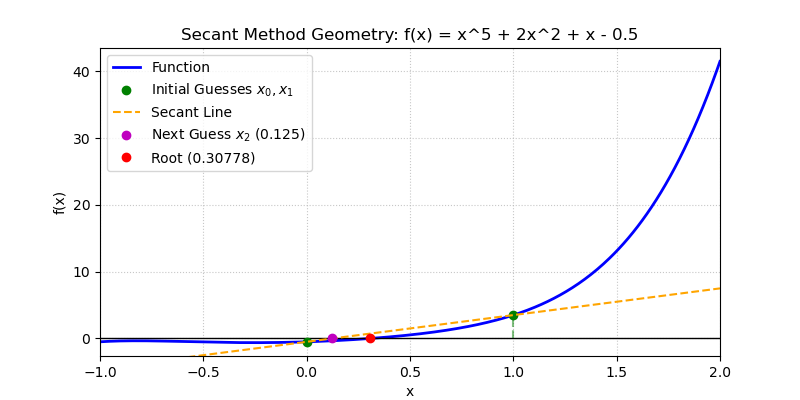


--- 3. False Position Method (Interval a = 0.0, b = 1.0) ---


,Iteration,a,b,c (root approx),f(c),Error
0,1,0.000000,1.0,0.125000,-0.343719,NaN
1,2,0.125000,1.0,0.203246,-0.213790,7.824571e-02
2,3,0.203246,1.0,0.249112,-0.125815,4.586635e-02
3,4,0.249112,1.0,0.275168,-0.071820,2.605565e-02
4,5,0.275168,1.0,0.289742,-0.040315,1.457453e-02
5,6,0.289742,1.0,0.297830,-0.022421,8.087920e-03
6,7,0.297830,1.0,0.302300,-0.012406,4.469443e-03
7,8,0.302300,1.0,0.304764,-0.006845,2.464264e-03
8,9,0.304764,1.0,0.306121,-0.003771,1.357022e-03
9,10,0.306121,1.0,0.306868,-0.002076,7.467839e-04


Final Root: 0.307780


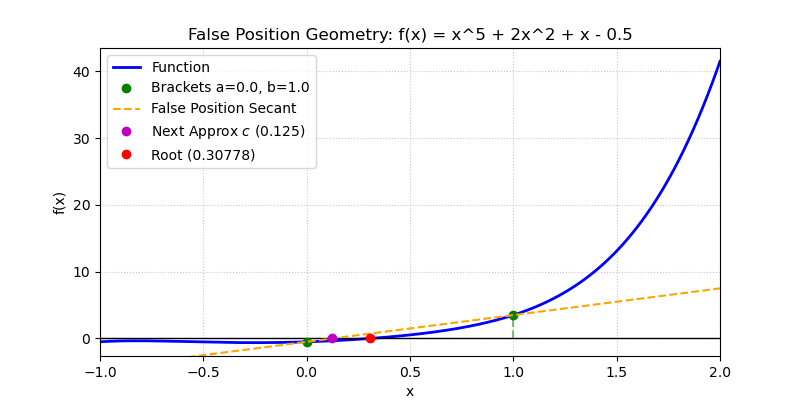

In [16]:
# ==========================================
# EXECUTION: RUNNING THE BENCHMARK & PLOTTING ALL METHODS
# ==========================================
from IPython.display import display

for i, (f, df, name, a, b) in enumerate(functions):
    print("="*80)
    print(f"BENCHMARK {i+1}: {name}")
    print("="*80)
    
    # ---------------------------------------------------------
    # 1. Newton-Raphson Method
    # ---------------------------------------------------------
    print(f"\n--- 1. Newton-Raphson Method (Initial guess x0 = {b}) ---")
    root_nr, df_nr, x1_first = newton_raphson(f, df, x0=b)
    display(df_nr) 
    print(f"Final Root: {root_nr:.6f}")
    plot_newton_step(f, df, x0=b, root=root_nr, x1_first=x1_first, title=name)
    
    # ---------------------------------------------------------
    # 2. Secant Method
    # ---------------------------------------------------------
    print(f"\n--- 2. Secant Method (Initial guesses x0 = {a}, x1 = {b}) ---")
    root_sec, df_sec = secant_method(f, x0=a, x1=b)
    display(df_sec)
    print(f"Final Root: {root_sec:.6f}")
    plot_secant_step(f, x0=a, x1=b, root=root_sec, title=name)
    
    # ---------------------------------------------------------
    # 3. False Position Method
    # ---------------------------------------------------------
    print(f"\n--- 3. False Position Method (Interval a = {a}, b = {b}) ---")
    root_fp, df_fp = false_position(f, a=a, b=b)
    if root_fp is not None:
        display(df_fp)
        print(f"Final Root: {root_fp:.6f}")
        plot_false_position_step(f, a=a, b=b, root=root_fp, title=name)
    
    print("\n" * 2) # Add some spacing between benchmarks